In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/advertising-sales-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'advertising-sales-dataset' dataset.
Path to dataset files: /kaggle/input/advertising-sales-dataset


In [21]:
import os

path = "/root/.cache/kagglehub/datasets/yasserh/advertising-sales-dataset/versions/1"

print(os.listdir(path))

['Advertising Budget and Sales.csv']


In [22]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import os

# ================================
# 2. Load Dataset
# ================================
file_path = "/root/.cache/kagglehub/datasets/yasserh/advertising-sales-dataset/versions/1/Advertising Budget and Sales.csv"

df = pd.read_csv(file_path)

print("First 5 rows:")
print(df.head())

# ================================
# 3. Clean Data (IMPORTANT)
# ================================
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")
df.columns = df.columns.str.replace("$", "")

print("\nCleaned Columns:", df.columns)

First 5 rows:
   Unnamed: 0  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  \
0           1             230.1                 37.8                     69.2   
1           2              44.5                 39.3                     45.1   
2           3              17.2                 45.9                     69.3   
3           4             151.5                 41.3                     58.5   
4           5             180.8                 10.8                     58.4   

   Sales ($)  
0       22.1  
1       10.4  
2        9.3  
3       18.5  
4       12.9  

Cleaned Columns: Index(['Unnamed:_0', 'TV_Ad_Budget_', 'Radio_Ad_Budget_',
       'Newspaper_Ad_Budget_', 'Sales_'],
      dtype='object')


In [23]:
# ================================
# 4. Data Description
# ================================
print("\nDataset Info:")
print(df.info())

print("\nSummary Statistics:")
print(df.describe())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed:_0            200 non-null    int64  
 1   TV_Ad_Budget_         200 non-null    float64
 2   Radio_Ad_Budget_      200 non-null    float64
 3   Newspaper_Ad_Budget_  200 non-null    float64
 4   Sales_                200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Summary Statistics:
       Unnamed:_0  TV_Ad_Budget_  Radio_Ad_Budget_  Newspaper_Ad_Budget_  \
count  200.000000     200.000000        200.000000            200.000000   
mean   100.500000     147.042500         23.264000             30.554000   
std     57.879185      85.854236         14.846809             21.778621   
min      1.000000       0.700000          0.000000              0.300000   
25%     50.750000      74.375000          9.975000             12.75

In [24]:
print(df.columns)

Index(['Unnamed:_0', 'TV_Ad_Budget_', 'Radio_Ad_Budget_',
       'Newspaper_Ad_Budget_', 'Sales_'],
      dtype='object')


In [25]:
# index column
df = df.drop(columns=['Unnamed:_0'])

# rename
df.columns = ['TV', 'Radio', 'Newspaper', 'Sales']

print(df.columns)

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')


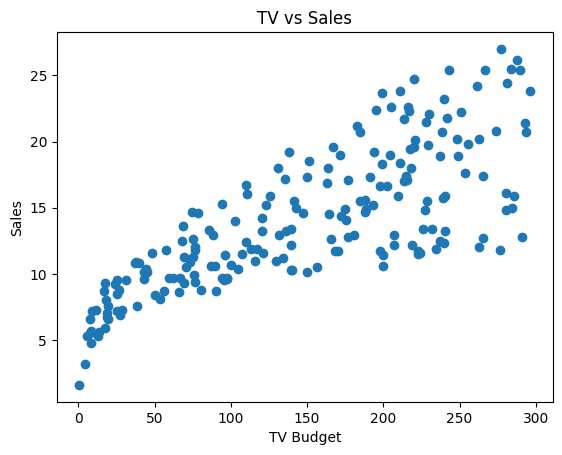

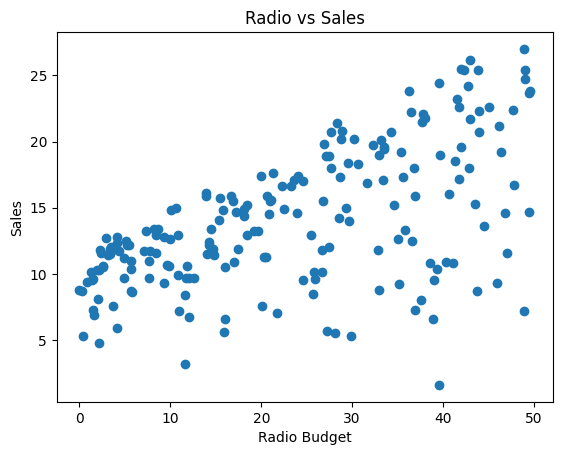

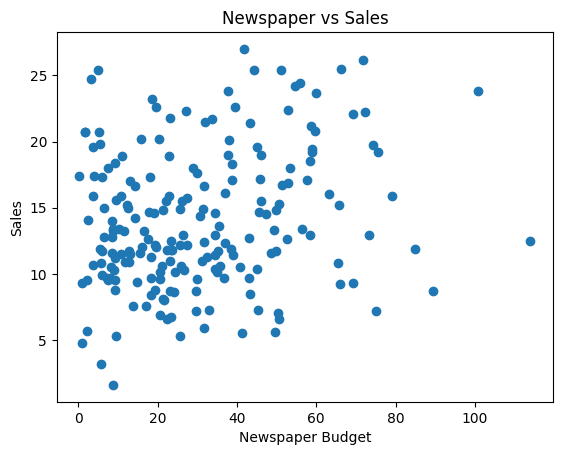

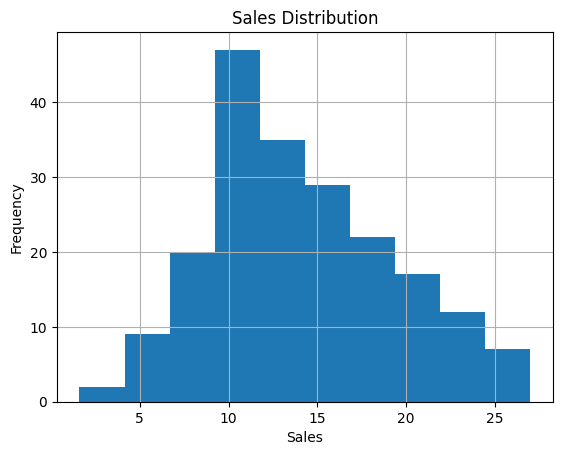

In [26]:
import matplotlib.pyplot as plt

# TV
plt.figure()
plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

# Radio
plt.figure()
plt.scatter(df['Radio'], df['Sales'])
plt.xlabel("Radio Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

# Newspaper
plt.figure()
plt.scatter(df['Newspaper'], df['Sales'])
plt.xlabel("Newspaper Budget")
plt.ylabel("Sales")
plt.title("Newspaper vs Sales")
plt.show()

# Histogram
plt.figure()
df['Sales'].hist()
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

=== Hypothesis Test (TV effect) ===
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           1.47e-42
Time:                        12:17:34   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7

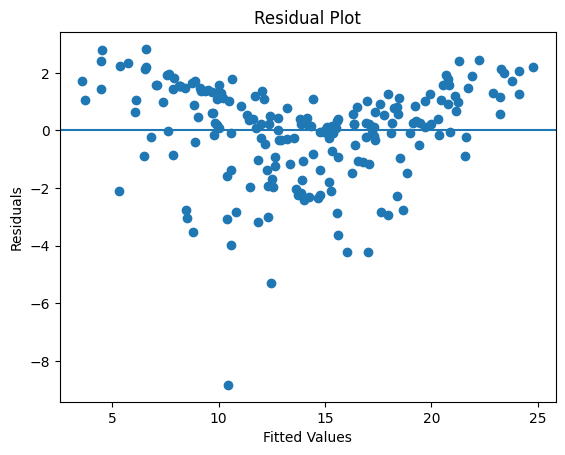


=== Interpretation ===
const: 2.938889369459406
TV: 0.04576464545539762
Radio: 0.18853001691820434
Newspaper: -0.0010374930424761793

Predicted Sales: 11.275579322938492


In [27]:
# =========================================================
# 6. Hypothesis Testing (Inference)
# =========================================================
import statsmodels.api as sm

# ทดสอบว่า TV มีผลต่อ Sales ไหม
X_tv = sm.add_constant(df['TV'])
model_tv = sm.OLS(df['Sales'], X_tv).fit()

print("=== Hypothesis Test (TV effect) ===")
print(model_tv.summary())

# =========================================================
# 7. Multiple Linear Regression
# =========================================================
X = df[['TV', 'Radio', 'Newspaper']]
Y = df['Sales']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print("\n=== Multiple Regression Model ===")
print(model.summary())

# =========================================================
# 8. Model Evaluation
# =========================================================

# R-squared
print("\nR-squared:", model.rsquared)

# Residual Plot
import matplotlib.pyplot as plt

residuals = model.resid

plt.figure()
plt.scatter(model.fittedvalues, residuals)
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.axhline(y=0)
plt.show()

# =========================================================
# 9. Interpretation (print ช่วยเขียน report)
# =========================================================
print("\n=== Interpretation ===")

for name, coef in model.params.items():
    print(f"{name}: {coef}")

# =========================================================
# 10. Simple Prediction
# =========================================================
new_data = pd.DataFrame({
    'const': [1],
    'TV': [100],
    'Radio': [20],
    'Newspaper': [10]
})

prediction = model.predict(new_data)
print("\nPredicted Sales:", prediction.iloc[0])